<a href="https://colab.research.google.com/github/MonaKhadija/colab-git-assignment2-kb/blob/main/Lesson_7_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Assignment 7: House Price Prediction Using Boston Housing Data**

Student name: Khadija Bassiouni

## **Assignment Supervised machine Learning - Regression**

### **_House Price Prediction Using Bolton Housing Data_**
This dataset provides information about house prices in Bolton. House Price Prediction


**In this notebook, you'll follow the basic machine learning process to build a regression model to predict house prices using the "Boston Housing Dataset" from sklearn. The regression model will either be a Decision Tree or Random Forest regressor.**



---



### **Follow the instructions and complete each TODO to complete the assessment on the essential steps in building and evaluating a regression model.**


The following is a description of each column in the dataset:

Dataset Features (Bolton Housing):

* CRIM: Crime rate by town
* ZN: Proportion of residential land zoned for large lots
* INDUS: Proportion of non-retail business acres per town
* CHAS: Charles River dummy variable (1 if tract bounds river; 0 otherwise)
* NOX: Nitric oxide concentration (parts per 10 million)
* RM: Average number of rooms per dwelling
* AGE: Proportion of owner-occupied units built before 1940
* DIS: Weighted distances to five Boston employment centers
* RAD: Index of accessibility to radial highways
* TAX: Full-value property tax rate per `$10,000`
* PTRATIO: Pupil-teacher ratio by town
* B: Proportion of Black population
* LSTAT: Percentage of lower status of the population
* MEDV (Target): Median value of owner-occupied homes in `$1,000s`



**Dataset is from sklearn Datasets**

In [1]:
# --- Imports ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
# --- Data Collection and Loading ---
from sklearn.datasets import fetch_openml

# Fetching Boston dataset from OpenML
boston = fetch_openml(name='boston', version=1, as_frame=True)

# Separate features and target
df = boston.frame

# Rename target column
if 'MEDV' not in df.columns:
    df.rename(columns={'MEDV0': 'MEDV'}, inplace=True)

In [4]:
# --- Quick Check of Data ---
# first 5 rows
print("Head of Data:")
print(df.head())

# Data info and types
print("\nData Info:")
df.info()

# Statistical overview
print("\nSummary Statistics:")
print(df.describe())

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

Head of Data:
      CRIM    ZN  INDUS CHAS    NOX     RM   AGE     DIS RAD    TAX  PTRATIO  \
0  0.00632  18.0   2.31    0  0.538  6.575  65.2  4.0900   1  296.0     15.3   
1  0.02731   0.0   7.07    0  0.469  6.421  78.9  4.9671   2  242.0     17.8   
2  0.02729   0.0   7.07    0  0.469  7.185  61.1  4.9671   2  242.0     17.8   
3  0.03237   0.0   2.18    0  0.458  6.998  45.8  6.0622   3  222.0     18.7   
4  0.06905   0.0   2.18    0  0.458  7.147  54.2  6.0622   3  222.0     18.7   

        B  LSTAT  MEDV  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90   5.33  36.2  

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   CRIM     506 non-null    float64 
 1   ZN       506 non-null    float64 
 2   INDUS    506 non-null    float64 
 3   CHAS     506 non-null    category
 4  

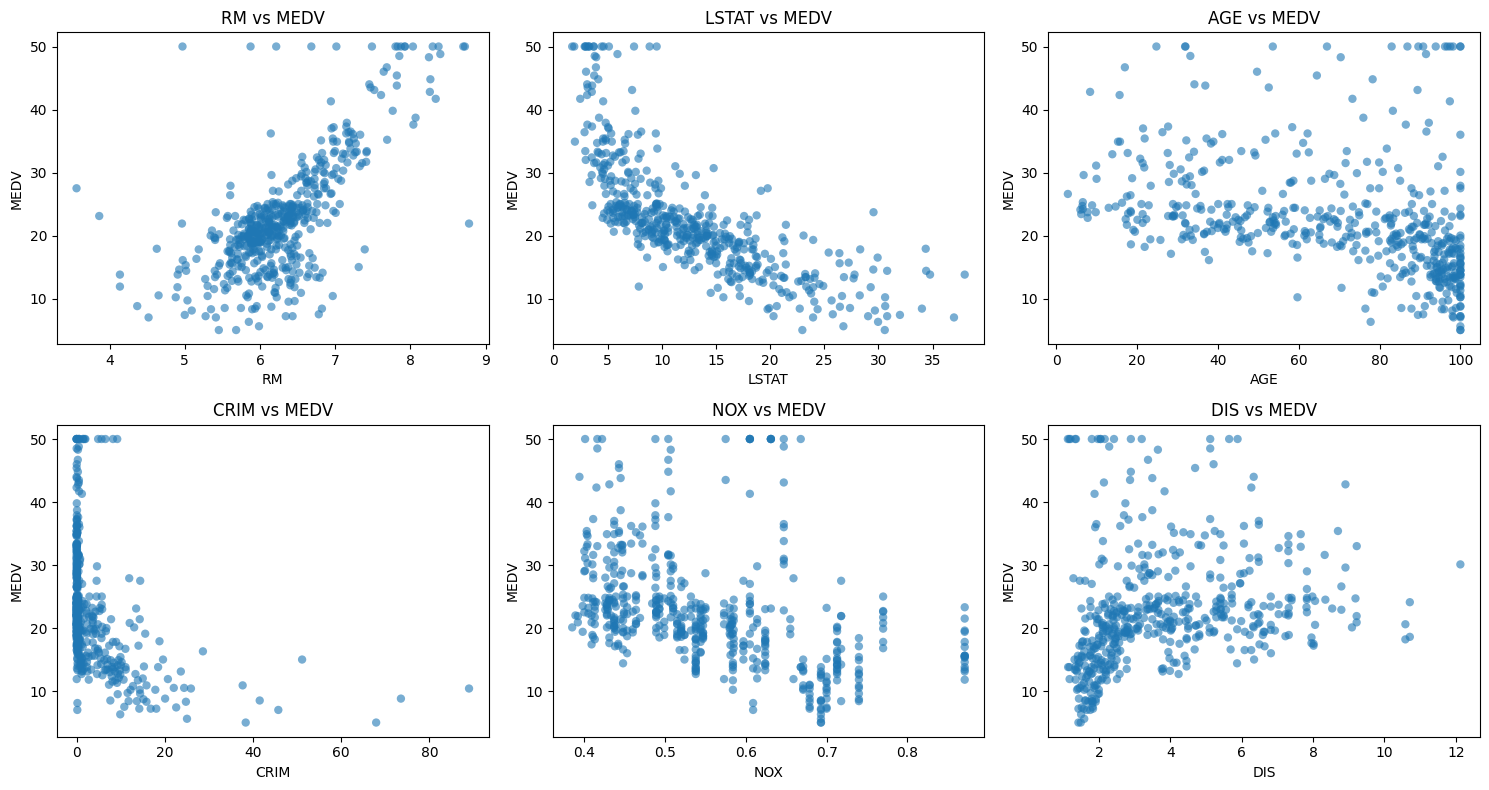

In [5]:
# --- EDA and Data Preprocessing ---
# Automated scatter plot function
def plot_scatter_vs_target(dataframe, features, target_col):
    num_features = len(features)
    cols = 3
    rows = (num_features + cols - 1) // cols

    plt.figure(figsize=(15, 4 * rows))
    for i, col in enumerate(features):
        plt.subplot(rows, cols, i + 1)
        plt.scatter(dataframe[col], dataframe[target_col], alpha=0.6, edgecolors='none')
        plt.xlabel(col)
        plt.ylabel(target_col)
        plt.title(f'{col} vs {target_col}')
    plt.tight_layout()
    plt.show()

# Running visualization function
selected_features = ['RM', 'LSTAT', 'AGE', 'CRIM', 'NOX', 'DIS']
plot_scatter_vs_target(df, selected_features, 'MEDV')

In [6]:
# --- ML Model Training ---
# Feature and Target Split
X = df.drop(columns=['MEDV'])
y = df['MEDV']

# Train/Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Grid Search for Hyperparameter Tuning on Random Forest
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

rf = RandomForestRegressor(random_state=42)
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
print(f"Best Parameters: {grid_search.best_params_}")

Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}


In [7]:
# --- Model Evaluation ---
# Predict on Test Set
y_pred = best_model.predict(X_test)

# Metrics calculation
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared Score (R2): {r2:.4f}")

Root Mean Squared Error (RMSE): 2.8110
R-squared Score (R2): 0.8923


In [8]:
# --- Model Prediction ---

# Sample input feature vector matching dataset order
new_sample = pd.DataFrame([{
    'CRIM': 0.2, 'ZN': 12.5, 'INDUS': 7.07, 'CHAS': 0,
    'NOX': 0.5, 'RM': 6.5, 'AGE': 68.0, 'DIS': 4.0,
    'RAD': 2, 'TAX': 250, 'PTRATIO': 17.0, 'B': 400.0, 'LSTAT': 12.0
}])

predicted_price = best_model.predict(new_sample)
print(f"Predicted Median Home Price: ${predicted_price[0] * 1000:,.2f}")

Predicted Median Home Price: $22,189.00
